# AI012 PyTorch Autoencoder Optimization

Unsupervised PyTorch autoencoder optimization for PHOENIX AI012 anomaly detection. The model learns reconstruction patterns from engineered AI012 features, then uses reconstruction error as the anomaly score.

## Supervised vs Unsupervised Evaluation

The active path is unsupervised: no label file, no target column, and no stratified split. Thresholds are tuned from reconstruction score quantiles and the configured contamination rate. Supervised metrics and curves are intentionally disabled unless trusted labels are explicitly enabled in a later experiment.

In [1]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import yaml
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.tensorboard import SummaryWriter


def find_ai012_root(start=None):
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if path.name == "ai012-anomaly":
            return path
        candidate = path / "ai-ml" / "models" / "ai012-anomaly"
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate ai-ml/models/ai012-anomaly")


AI012_ROOT = find_ai012_root()
SRC_DIR = AI012_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from features.feature_selector import FeatureSelector

sns.set_theme(style="whitegrid")
AI012_ROOT

WindowsPath('C:/Users/koolg/OneDrive - Deakin University/PHOENIX/Phoenix Github Repo/ai-ml/models/ai012-anomaly')

In [2]:
MODEL_NAME = "autoencoder"
CONFIG_PATH = AI012_ROOT / "autoencoder" / "configs" / "autoencoder_config.yaml"

with CONFIG_PATH.open("r", encoding="utf-8") as handle:
    config = yaml.safe_load(handle)


def resolve_config_path(value):
    if not value:
        return None
    path = Path(value)
    if path.is_absolute():
        return path
    return (CONFIG_PATH.parent / path).resolve()


dataset_path = resolve_config_path(config["dataset"]["path"])
reports_dir = resolve_config_path(config["outputs"]["reports_dir"])
graphs_dir = resolve_config_path(config["outputs"]["graphs_dir"])
checkpoints_dir = resolve_config_path(config["outputs"]["checkpoints_dir"])
logs_dir = resolve_config_path(config["outputs"]["logs_dir"])
tb_root = resolve_config_path(config["training"]["tensorboard_log_dir"])
tb_run_dir = tb_root / config["training"].get("tensorboard_run_name", MODEL_NAME)

for directory in [reports_dir, graphs_dir, checkpoints_dir, logs_dir, tb_run_dir]:
    directory.mkdir(parents=True, exist_ok=True)

assert config["dataset"].get("evaluation_mode") == "unsupervised"
assert config["dataset"].get("target_column") is None
assert dataset_path.exists(), dataset_path

seed = config["dataset"].get("random_seed", 42)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dataset:", dataset_path)
print("Device:", device)
print("TensorBoard:", tb_run_dir)

Dataset: C:\Users\koolg\OneDrive - Deakin University\PHOENIX\Phoenix Github Repo\ai-ml\datasets\anomaly_detection_hourly_2020_2024.csv
Device: cpu
TensorBoard: C:\Users\koolg\OneDrive - Deakin University\PHOENIX\Phoenix Github Repo\ai-ml\models\ai012-anomaly\logs\tensorboard\ai012_anomaly_optimization\autoencoder


In [3]:
df_raw = pd.read_csv(dataset_path, low_memory=False)
df = FeatureSelector(df_raw).create_features()

drop_columns = set(config["preprocessing"].get("drop_columns", []))
drop_columns.update({"label", "is_anomaly", "anomaly_label", "anomaly_flag", "anomaly_score", "anomaly_rank"})

selected_features = config["preprocessing"].get("selected_features") or []
if selected_features:
    feature_columns = [col for col in selected_features if col in df.columns and col not in drop_columns]
else:
    feature_columns = [col for col in df.select_dtypes(include=[np.number]).columns if col not in drop_columns]

X = df[feature_columns].replace([np.inf, -np.inf], np.nan)

train_size = config["dataset"].get("train_split", 0.7)
val_size = config["dataset"].get("val_split", 0.15)
test_size = config["dataset"].get("test_split", 0.15)

X_train, X_tmp = train_test_split(X, train_size=train_size, shuffle=True, random_state=seed)
relative_val_size = val_size / (val_size + test_size)
X_val, X_test = train_test_split(X_tmp, train_size=relative_val_size, shuffle=True, random_state=seed)

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy=config["preprocessing"].get("missing_value_strategy", "median"))),
    ("scaler", StandardScaler()),
])

X_train_scaled = preprocessor.fit_transform(X_train).astype(np.float32)
X_val_scaled = preprocessor.transform(X_val).astype(np.float32)
X_test_scaled = preprocessor.transform(X_test).astype(np.float32)

print("Raw shape:", df_raw.shape)
print("Feature shape:", X.shape)
print("Split sizes:", len(X_train), len(X_val), len(X_test))

Raw shape: (169539, 45)
Feature shape: (169539, 50)
Split sizes: 118677 25431 25431


In [4]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoder_layers, latent_dim, decoder_layers, dropout=0.0):
        super().__init__()
        encoder = []
        previous = input_dim
        for width in encoder_layers:
            encoder.extend([nn.Linear(previous, width), nn.ReLU()])
            if dropout:
                encoder.append(nn.Dropout(dropout))
            previous = width
        encoder.append(nn.Linear(previous, latent_dim))

        decoder = []
        previous = latent_dim
        for width in decoder_layers:
            decoder.extend([nn.Linear(previous, width), nn.ReLU()])
            if dropout:
                decoder.append(nn.Dropout(dropout))
            previous = width
        decoder.append(nn.Linear(previous, input_dim))

        self.encoder = nn.Sequential(*encoder)
        self.decoder = nn.Sequential(*decoder)

    def forward(self, x):
        return self.decoder(self.encoder(x))


hp = config["model"]["hyperparameters"]
training_cfg = config["training"]

model = Autoencoder(
    input_dim=X_train_scaled.shape[1],
    encoder_layers=hp.get("encoder_layers", [128, 64, 32]),
    latent_dim=hp.get("latent_dim", 16),
    decoder_layers=hp.get("decoder_layers", [32, 64, 128]),
    dropout=hp.get("dropout", 0.1),
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=training_cfg.get("learning_rate", 0.001),
    weight_decay=training_cfg.get("weight_decay", 0.0),
)
criterion = nn.MSELoss()

batch_size = training_cfg.get("batch_size", 256)
train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train_scaled)), batch_size=batch_size, shuffle=True)
val_tensor = torch.from_numpy(X_val_scaled).to(device)

model

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=50, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=32, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=128, out_features=50, bias=True)
  )
)

In [5]:
epochs = training_cfg.get("epochs", 50)
early_stopping = training_cfg.get("early_stopping", {})
patience = early_stopping.get("patience", 8) if early_stopping.get("enabled", True) else epochs
min_delta = early_stopping.get("min_delta", 0.0001)

writer = SummaryWriter(log_dir=str(tb_run_dir)) if training_cfg.get("tensorboard_enabled", False) else None
best_val_loss = float("inf")
best_epoch = -1
best_state_dict = None
epochs_without_improvement = 0
history = []
best_checkpoint_path = checkpoints_dir / "autoencoder_best.pt"

for epoch in range(1, epochs + 1):
    model.train()
    train_losses = []
    for (batch,) in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        reconstruction = model(batch)
        loss = criterion(reconstruction, batch)
        loss.backward()
        optimizer.step()
        train_losses.append(float(loss.detach().cpu()))

    model.eval()
    with torch.no_grad():
        val_reconstruction = model(val_tensor)
        val_loss = float(criterion(val_reconstruction, val_tensor).detach().cpu())

    train_loss = float(np.mean(train_losses))
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

    if writer is not None:
        writer.add_scalar("loss/train", train_loss, epoch)
        writer.add_scalar("loss/val", val_loss, epoch)

    improved = val_loss < (best_val_loss - min_delta)
    if improved:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state_dict = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        epochs_without_improvement = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "feature_columns": feature_columns,
            "input_dim": X_train_scaled.shape[1],
            "config": config,
            "epoch": epoch,
            "val_loss": val_loss,
        }, best_checkpoint_path)
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 5 == 0 or improved:
        print(f"epoch={epoch:03d} train_loss={train_loss:.6f} val_loss={val_loss:.6f}")

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch}; best epoch was {best_epoch}.")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(reports_dir / "autoencoder_training_history.csv", index=False)

if best_state_dict is None:
    raise RuntimeError("Autoencoder did not produce a valid checkpoint.")

model.load_state_dict({key: value.to(device) for key, value in best_state_dict.items()})
checkpoint = {
    "model_state_dict": best_state_dict,
    "feature_columns": feature_columns,
    "input_dim": X_train_scaled.shape[1],
    "config": config,
    "epoch": best_epoch,
    "val_loss": best_val_loss,
}
print("Best checkpoint:", best_checkpoint_path)

epoch=001 train_loss=0.407160 val_loss=0.257689


epoch=002 train_loss=0.266657 val_loss=0.206530


epoch=003 train_loss=0.237122 val_loss=0.187891


epoch=004 train_loss=0.226021 val_loss=0.171027


epoch=005 train_loss=0.213488 val_loss=0.157199


...

epoch=010 train_loss=0.187346 val_loss=0.130602


epoch=014 train_loss=0.177379 val_loss=0.112916


epoch=015 train_loss=0.175915 val_loss=0.191191


epoch=020 train_loss=0.172902 val_loss=0.114758


Early stopping at epoch 22; best epoch was 14.
Best checkpoint: C:\Users\koolg\OneDrive - Deakin University\PHOENIX\Phoenix Github Repo\ai-ml\models\ai012-anomaly\autoencoder\outputs\checkpoints\autoencoder_best.pt


In [6]:
def reconstruction_scores(model, array):
    model.eval()
    tensor = torch.from_numpy(array).to(device)
    scores = []
    loader = DataLoader(TensorDataset(tensor), batch_size=training_cfg.get("batch_size", 256), shuffle=False)
    with torch.no_grad():
        for (batch,) in loader:
            reconstruction = model(batch)
            batch_scores = torch.mean((reconstruction - batch) ** 2, dim=1)
            scores.append(batch_scores.detach().cpu().numpy())
    return np.concatenate(scores)


val_scores = reconstruction_scores(model, X_val_scaled)
test_scores = reconstruction_scores(model, X_test_scaled)
threshold_quantile = 1.0 - config["evaluation"].get("default_contamination", 0.07)
threshold = float(np.quantile(val_scores, threshold_quantile))
test_flags = (test_scores >= threshold).astype(int)

checkpoint["threshold"] = threshold
torch.save(checkpoint, best_checkpoint_path)
joblib.dump({
    "preprocessor": preprocessor,
    "feature_columns": feature_columns,
    "threshold": threshold,
    "config": config,
}, checkpoints_dir / "autoencoder_preprocessing.pkl")

print("Threshold:", threshold)
print("Test anomaly rate:", test_flags.mean())

Threshold: 0.15401120483875275
Test anomaly rate: 0.07077975698950101


In [7]:
def score_iqr(values):
    q75, q25 = np.percentile(values, [75, 25])
    return float(q75 - q25)


def stability_from_scores(values, contamination, iterations=10, sample_fraction=0.8, seed=42):
    rng = np.random.default_rng(seed)
    rates = []
    values = np.asarray(values)
    sample_size = max(10, int(len(values) * sample_fraction))
    for _ in range(iterations):
        sample = rng.choice(values, size=sample_size, replace=False)
        sample_threshold = np.quantile(sample, 1.0 - contamination)
        rates.append(float((sample >= sample_threshold).mean()))
    mean_rate = float(np.mean(rates))
    std_rate = float(np.std(rates))
    return float(np.clip(1.0 - (std_rate / (mean_rate + 1e-9)), 0.0, 1.0))


contamination = config["evaluation"].get("default_contamination", 0.07)
stability_cfg = config["evaluation"].get("stability", {})
stability_score = stability_from_scores(
    test_scores,
    contamination=contamination,
    iterations=stability_cfg.get("bootstrap_iterations", 10),
    sample_fraction=stability_cfg.get("sample_fraction", 0.8),
    seed=seed,
)

metrics = {
    "model": MODEL_NAME,
    "evaluation_mode": "unsupervised",
    "n_rows": int(len(X)),
    "n_features": int(len(feature_columns)),
    "best_epoch": int(best_epoch),
    "best_val_loss": float(best_val_loss),
    "threshold": threshold,
    "threshold_quantile": threshold_quantile,
    "anomaly_rate": float(test_flags.mean()),
    "score_mean": float(np.mean(test_scores)),
    "score_std": float(np.std(test_scores)),
    "score_iqr": score_iqr(test_scores),
    "stability_score": stability_score,
    "precision": None,
    "recall": None,
    "f1": None,
    "roc_auc": None,
    "pr_auc": None,
    "false_positive_rate": None,
    "false_negative_rate": None,
}

results_path = resolve_config_path(config["outputs"]["results_file"])
with results_path.open("w", encoding="utf-8") as handle:
    json.dump(metrics, handle, indent=2)

scores_df = pd.DataFrame({"anomaly_score": test_scores, "anomaly_flag": test_flags})
scores_df.to_csv(resolve_config_path(config["outputs"]["scores_file"]), index=False)

quantiles = np.linspace(0.50, 0.995, config["evaluation"].get("threshold_grid_size", 101))
threshold_df = pd.DataFrame([
    {
        "threshold_quantile": float(q),
        "threshold": float(np.quantile(val_scores, q)),
        "anomaly_rate": float((test_scores >= np.quantile(val_scores, q)).mean()),
    }
    for q in quantiles
])
threshold_df.to_csv(resolve_config_path(config["outputs"]["threshold_file"]), index=False)

if writer is not None:
    common_tensorboard_scalars = {
        "dataset/n_rows": "n_rows",
        "dataset/n_features": "n_features",
        "metrics/anomaly_rate": "anomaly_rate",
        "metrics/score_mean": "score_mean",
        "metrics/score_std": "score_std",
        "metrics/score_iqr": "score_iqr",
        "metrics/stability_score": "stability_score",
        "threshold/value": "threshold",
        "threshold/quantile": "threshold_quantile",
    }
    threshold_tuning_scalars = ["threshold_quantile", "threshold", "anomaly_rate"]

    for idx, row in threshold_df.iterrows():
        for column in threshold_tuning_scalars:
            writer.add_scalar(f"tuning/{column}", row[column], idx)

    for tag, metric_name in common_tensorboard_scalars.items():
        value = metrics.get(metric_name)
        if value is not None:
            writer.add_scalar(tag, value, 0)

    writer.close()

metrics

{'model': 'autoencoder',
 'evaluation_mode': 'unsupervised',
 'n_rows': 169539,
 'n_features': 50,
 'best_epoch': 14,
 'best_val_loss': 0.11291617155075073,
 'threshold': 0.15401120483875275,
 'threshold_quantile': 0.9299999999999999,
 'anomaly_rate': 0.07077975698950101,
 'score_mean': 0.09331245720386505,
 'score_std': 0.327775239944458,
 'score_iqr': 0.043425239622592926,
 'stability_score': 1.0,
 'precision': None,
 'recall': None,
 'f1': None,
 'roc_auc': None,
 'pr_auc': None,
 'false_positive_rate': None,
 'false_negative_rate': None}

In [8]:
# Supervised threshold selection and held-out evaluation against Role C labels.
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

labels_path = AI012_ROOT / "data" / "processed" / "anomaly_labels_v1.csv"
if not labels_path.exists():
    from labeling.label_builder import run as build_labels

    labels_df = build_labels(dataset_path=str(dataset_path), save=False)
    labels_path.parent.mkdir(parents=True, exist_ok=True)
    labels_df.to_csv(labels_path, index=False)
else:
    labels_df = pd.read_csv(labels_path)

if len(labels_df) != len(df_raw):
    raise ValueError(f"Label row count {len(labels_df)} does not match dataset row count {len(df_raw)}")
if "anomaly_flag" not in labels_df.columns:
    raise ValueError("Expected anomaly_flag column in Role C labels")

y_all = labels_df["anomaly_flag"].astype(int)
y_val = y_all.loc[X_val.index].to_numpy()
y_test = y_all.loc[X_test.index].to_numpy()

supervised_threshold_rows = []
for _, row in threshold_df.iterrows():
    candidate_threshold = float(row["threshold"])
    val_flags = (val_scores >= candidate_threshold).astype(int)
    supervised_threshold_rows.append({
        "threshold_quantile": float(row["threshold_quantile"]),
        "threshold": candidate_threshold,
        "val_precision": precision_score(y_val, val_flags, zero_division=0),
        "val_recall": recall_score(y_val, val_flags, zero_division=0),
        "val_f1": f1_score(y_val, val_flags, zero_division=0),
        "val_anomaly_rate": float(val_flags.mean()),
    })

supervised_threshold_df = pd.DataFrame(supervised_threshold_rows)
supervised_threshold_df = supervised_threshold_df.sort_values(
    ["val_f1", "val_precision", "val_recall"], ascending=False
).reset_index(drop=True)
supervised_threshold = float(supervised_threshold_df.loc[0, "threshold"])
supervised_threshold_quantile = float(supervised_threshold_df.loc[0, "threshold_quantile"])
supervised_test_flags = (test_scores >= supervised_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, supervised_test_flags, labels=[0, 1]).ravel()

def safe_auc(metric_func, y_true, y_score):
    return float(metric_func(y_true, y_score)) if len(np.unique(y_true)) > 1 else None

supervised_metrics = {
    "model": MODEL_NAME,
    "evaluation_mode": "supervised",
    "supervision_type": "role_c_threshold_selection",
    "label_source": str(labels_path.relative_to(AI012_ROOT)),
    "n_rows": int(len(X)),
    "n_features": int(len(feature_columns)),
    "test_rows": int(len(y_test)),
    "label_anomaly_rate": float(y_test.mean()),
    "threshold": supervised_threshold,
    "threshold_quantile": supervised_threshold_quantile,
    "anomaly_rate": float(supervised_test_flags.mean()),
    "score_mean": float(np.mean(test_scores)),
    "score_std": float(np.std(test_scores)),
    "score_iqr": score_iqr(test_scores),
    "stability_score": stability_score,
    "precision": precision_score(y_test, supervised_test_flags, zero_division=0),
    "recall": recall_score(y_test, supervised_test_flags, zero_division=0),
    "f1": f1_score(y_test, supervised_test_flags, zero_division=0),
    "roc_auc": safe_auc(roc_auc_score, y_test, test_scores),
    "pr_auc": safe_auc(average_precision_score, y_test, test_scores),
    "false_positive_rate": float(fp / (fp + tn)) if (fp + tn) else None,
    "false_negative_rate": float(fn / (fn + tp)) if (fn + tp) else None,
    "true_negative": int(tn),
    "false_positive": int(fp),
    "false_negative": int(fn),
    "true_positive": int(tp),
}
if "epochs" in globals():
    supervised_metrics["training_epochs"] = int(epochs)
if "best_epoch" in globals():
    supervised_metrics["best_epoch"] = int(best_epoch)
if "best_val_loss" in globals():
    supervised_metrics["best_val_loss"] = float(best_val_loss)

base_results_path = resolve_config_path(config["outputs"]["results_file"])
supervised_results_path = base_results_path.with_name(f"{MODEL_NAME}_supervised_metrics.json")
with supervised_results_path.open("w", encoding="utf-8") as handle:
    json.dump(supervised_metrics, handle, indent=2)

base_scores_path = resolve_config_path(config["outputs"]["scores_file"])
supervised_scores_path = base_scores_path.with_name(f"{MODEL_NAME}_supervised_scores.csv")
pd.DataFrame({
    "anomaly_score": test_scores,
    "anomaly_flag": supervised_test_flags,
    "label_anomaly_flag": y_test,
}).to_csv(supervised_scores_path, index=False)

base_threshold_path = resolve_config_path(config["outputs"]["threshold_file"])
supervised_threshold_path = base_threshold_path.with_name(f"{MODEL_NAME}_supervised_threshold_tuning.csv")
supervised_threshold_df.to_csv(supervised_threshold_path, index=False)

if config["training"].get("tensorboard_enabled", False) and SummaryWriter is not None:
    supervised_tb_run_dir = tb_run_dir.parent / f"{config['training'].get('tensorboard_run_name', MODEL_NAME)}_supervised"
    supervised_tb_run_dir.mkdir(parents=True, exist_ok=True)
    writer = SummaryWriter(log_dir=str(supervised_tb_run_dir))
    supervised_tensorboard_scalars = {
        "dataset/n_rows": "n_rows",
        "dataset/n_features": "n_features",
        "labels/anomaly_rate": "label_anomaly_rate",
        "metrics/anomaly_rate": "anomaly_rate",
        "metrics/precision": "precision",
        "metrics/recall": "recall",
        "metrics/f1": "f1",
        "metrics/roc_auc": "roc_auc",
        "metrics/pr_auc": "pr_auc",
        "metrics/false_positive_rate": "false_positive_rate",
        "metrics/false_negative_rate": "false_negative_rate",
        "metrics/score_mean": "score_mean",
        "metrics/score_std": "score_std",
        "metrics/score_iqr": "score_iqr",
        "metrics/stability_score": "stability_score",
        "threshold/value": "threshold",
        "threshold/quantile": "threshold_quantile",
    }
    for idx, row in supervised_threshold_df.sort_values("threshold_quantile").reset_index(drop=True).iterrows():
        writer.add_scalar("tuning/val_precision", row["val_precision"], idx)
        writer.add_scalar("tuning/val_recall", row["val_recall"], idx)
        writer.add_scalar("tuning/val_f1", row["val_f1"], idx)
        writer.add_scalar("tuning/val_anomaly_rate", row["val_anomaly_rate"], idx)
        writer.add_scalar("tuning/threshold", row["threshold"], idx)
        writer.add_scalar("tuning/threshold_quantile", row["threshold_quantile"], idx)
    for tag, metric_name in supervised_tensorboard_scalars.items():
        value = supervised_metrics.get(metric_name)
        if value is not None:
            writer.add_scalar(tag, value, 0)
    writer.close()
    print("Supervised TensorBoard logs written to:", supervised_tb_run_dir)

supervised_metrics


Supervised TensorBoard logs written to: C:\Users\koolg\OneDrive - Deakin University\PHOENIX\Phoenix Github Repo\ai-ml\models\ai012-anomaly\logs\tensorboard\ai012_anomaly_optimization\autoencoder_supervised


{'model': 'autoencoder',
 'evaluation_mode': 'supervised',
 'supervision_type': 'role_c_threshold_selection',
 'label_source': 'data\\processed\\anomaly_labels_v1.csv',
 'n_rows': 169539,
 'n_features': 50,
 'test_rows': 25431,
 'label_anomaly_rate': 0.06912822932641265,
 'threshold': 0.15464651318639505,
 'threshold_quantile': 0.93065,
 'anomaly_rate': 0.0700326373323896,
 'score_mean': 0.09331245720386505,
 'score_std': 0.327775239944458,
 'score_iqr': 0.043425239622592926,
 'stability_score': 1.0,
 'precision': 0.5440763615946098,
 'recall': 0.5511945392491467,
 'f1': 0.5476123198643684,
 'roc_auc': 0.8942232302685715,
 'pr_auc': 0.5460367249064946,
 'false_positive_rate': 0.03430068009969163,
 'false_negative_rate': 0.44880546075085326,
 'true_negative': 22861,
 'false_positive': 812,
 'false_negative': 789,
 'true_positive': 969,
 'training_epochs': 50,
 'best_epoch': 14,
 'best_val_loss': 0.11291617155075073}

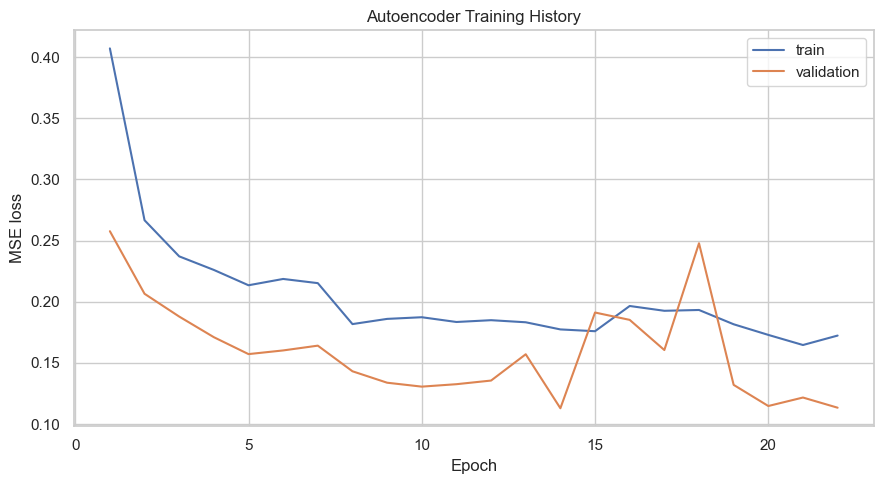

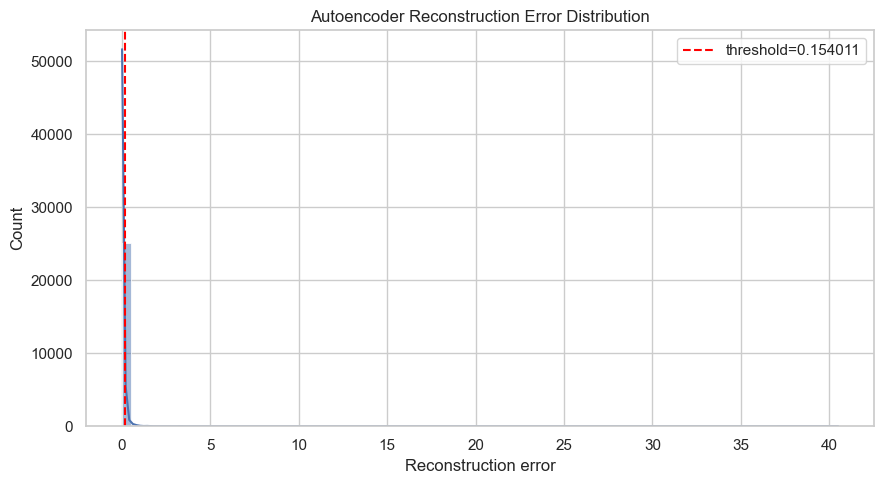

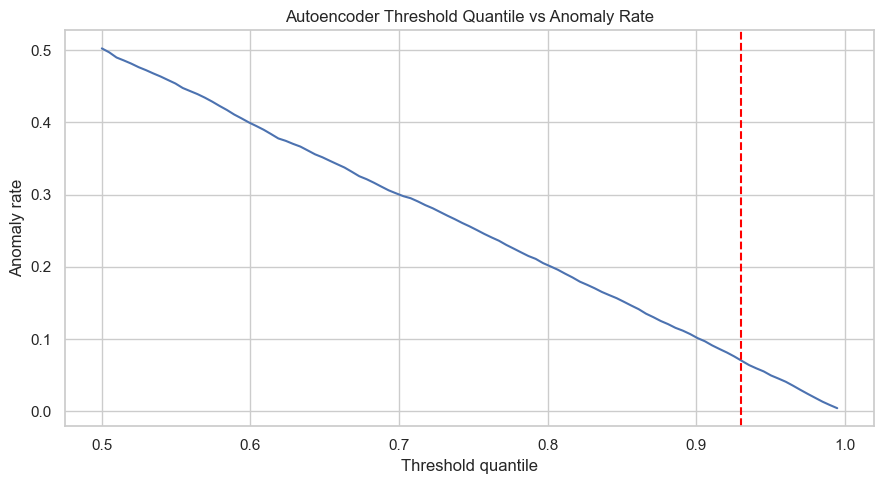

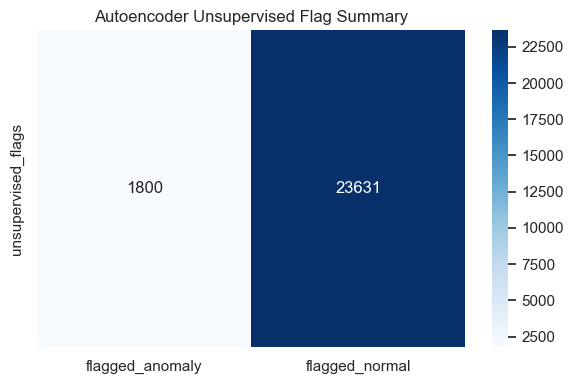

TensorBoard logs written to: C:\Users\koolg\OneDrive - Deakin University\PHOENIX\Phoenix Github Repo\ai-ml\models\ai012-anomaly\logs\tensorboard\ai012_anomaly_optimization\autoencoder


In [9]:
plt.figure(figsize=(9, 5))
sns.lineplot(data=history_df, x="epoch", y="train_loss", label="train")
sns.lineplot(data=history_df, x="epoch", y="val_loss", label="validation")
plt.title("Autoencoder Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.tight_layout()
plt.savefig(graphs_dir / "autoencoder_training_history.png", dpi=150)
plt.show()

plt.figure(figsize=(9, 5))
sns.histplot(test_scores, bins=80, kde=True)
plt.axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.6f}")
plt.title("Autoencoder Reconstruction Error Distribution")
plt.xlabel("Reconstruction error")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(graphs_dir / "autoencoder_score_distribution.png", dpi=150)
plt.show()

plt.figure(figsize=(9, 5))
sns.lineplot(data=threshold_df, x="threshold_quantile", y="anomaly_rate")
plt.axvline(threshold_quantile, color="red", linestyle="--")
plt.title("Autoencoder Threshold Quantile vs Anomaly Rate")
plt.xlabel("Threshold quantile")
plt.ylabel("Anomaly rate")
plt.tight_layout()
plt.savefig(graphs_dir / "autoencoder_threshold_vs_anomaly_rate.png", dpi=150)
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(pd.DataFrame([[test_flags.sum(), len(test_flags) - test_flags.sum()]], columns=["flagged_anomaly", "flagged_normal"], index=["unsupervised_flags"]), annot=True, fmt="d", cmap="Blues")
plt.title("Autoencoder Unsupervised Flag Summary")
plt.tight_layout()
plt.savefig(graphs_dir / "autoencoder_unsupervised_flag_summary.png", dpi=150)
plt.show()

print("TensorBoard logs written to:", tb_run_dir)